# Import libraries

In [1]:
import torch
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import clip
import math
import matplotlib.pyplot as plt
import dnnlib
import legacy
from IPython import display

# Load clip2style Matrix

In [ ]:
clip2style_matrix = np.load("clip_data/clip2styles.npy")

# Define Clip2Style Mapper
Only run one of the cells.

In [ ]:
class Clip2StyleMapper(torch.nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(512, 1024),
            torch.nn.ReLU(),
            torch.nn.Linear(1024, 2048),
            torch.nn.ReLU(),
            torch.nn.Linear(2048, 4096),
            torch.nn.ReLU(),
            torch.nn.Linear(4096, 6048)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class Clip2StyleMapper(torch.nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()            
        self.net = torch.nn.Sequential(torch.nn.Linear(in_dim, out_dim))

    def forward(self, x):
        return self.net(x)

# <span style="color:orange">Stage 1 training - Training loop</span>

Stage 1 training leverages the  $\text{CLIP2Style}$ matrix. Specifically, the  $\text{CLIP2StyleMapper}$ is initially trained to learn the transformation represented by the operation: $\text{styles\_vector}_{\text{6048}} = \text{clip2style}_{\text{6048 x 512}} \cdot \text{clip\_direction}_{\text{512}}$

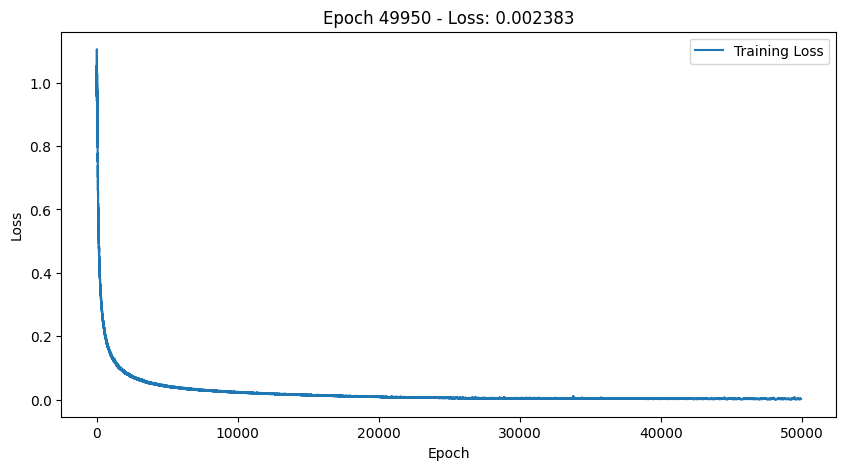

In [ ]:
# 1. Setup Data and Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Clip2StyleMapper(in_dim=512, out_dim=6048).to(device)
learning_rate = 1e-4
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = torch.nn.MSELoss()

# clip2styles_matrix shape: (6048, 512)
matrix_gt = torch.from_numpy(clip2style_matrix).float().to(device)

# 2. Training Loop
epochs = 50000
batch_size = 64

losses = []

for epoch in range(epochs):
    # Generate synthetic input (CLIP direction)
    inputs = torch.randn(batch_size, 512).to(device)
    
    # Calculate ground truth: (batch, 6048)
    with torch.no_grad():
        targets = inputs @ matrix_gt.t()

    # Forward pass
    outputs = model(inputs)
    loss = criterion(outputs, targets)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 50 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}")
        display.clear_output(wait=True)
        plt.figure(figsize=(10, 5))
        plt.plot(losses, label='Training Loss')
        plt.title(f'Epoch {epoch} - Loss: {loss.item():.6f}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

# Save the model

In [ ]:
torch.save(model.state_dict(), 'out/mapping_network.pth')

# Load the model

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
clip2styles_mapper = Clip2StyleMapper(in_dim=512, out_dim=6048).to(device)
clip2styles_mapper.load_state_dict(torch.load('out/mapping_network.pth'))

<All keys matched successfully>

# Helper functions

In [4]:
def plot_tensor_images(images, titles=None, cols=4, figsize=4):
    if not isinstance(images, list):
        images = [images]

    n = len(images)
    rows = math.ceil(n / cols)

    plt.figure(figsize=(cols * figsize, rows * figsize))

    for i, img in enumerate(images):
        img = (img.permute(0, 2, 3, 1) * 127.5 + 128).clamp(0, 255).to(torch.uint8)
        pil_img = Image.fromarray(img[0].cpu().numpy(), "RGB")
        plt.subplot(rows, cols, i + 1)
        plt.imshow(pil_img)
        plt.axis("off")

        if titles and i < len(titles):
            plt.title(titles[i], fontsize=10)

    plt.tight_layout()
    plt.show()

# StyleAffineMapper and StyleSynthesisNetwork
StyleAffineMapper: $\text{z\_vector} \rightarrow \text{style\_vectors}$

StyleSynthesisNetwork: $\text{style\_vectors} \rightarrow \text{image}$

In [4]:
class StyleAffineMapper(torch.nn.Module):
    def __init__(self, mapping, affines):
        super().__init__()
        self.mapping = mapping
        self.affines = torch.nn.ModuleList(affines)

    def forward(self, z, truncation=0.5):
        w = self.mapping(z, None, truncation_psi=truncation)  # shape [batch, 14, 512]

        outputs = []

        # Handle First Block
        outputs.append(self.affines[0](w[:, 0]))  # conv1
        outputs.append(self.affines[1](w[:, 1]))  # toRGB

        # Rest of the blocks
        w_idx = 2
        affine_idx = 2
        for _ in range(8):
            # conv0
            outputs.append(self.affines[affine_idx](w[:, w_idx]))
            # conv1
            outputs.append(self.affines[affine_idx + 1](w[:, w_idx + 1]))
            # toRGB (reuses the second w vector of this block)
            outputs.append(self.affines[affine_idx + 2](w[:, w_idx + 1]))

            w_idx += 2
            affine_idx += 3

        return outputs

In [5]:
class StyleSynthesisNetwork(torch.nn.Module):
    def __init__(self, synthesis):
        super().__init__()
        self.synthesis = synthesis
        
        for name, module in self.synthesis.named_modules():
            if hasattr(module, 'affine'):
                module.affine = torch.nn.Identity()

    def forward(self, precomputed_styles):

        style_idx = 0
        
        def hooked_forward(module, input):
            nonlocal style_idx
            new_input = list(input)
            new_input[1] = precomputed_styles[style_idx]
            style_idx += 1
            return tuple(new_input)

        hooks = []
        for name, module in self.synthesis.named_modules():
            if hasattr(module, 'affine'):
                hooks.append(module.register_forward_pre_hook(hooked_forward)) # pre-hook to replace the style input with precomputed styles

        try:
            dummy_ws = torch.zeros(precomputed_styles[0].shape[0],
                                   self.synthesis.num_ws, 512).to(precomputed_styles[0].device) # use a dummy tensor since styles are loaded via hooks
            img = self.synthesis(dummy_ws)
        finally:
            for h in hooks:
                h.remove()
                
        return img

## Load styleGAN2 ffhq model and extract the mapping network, affine layers

In [6]:
network_pkl = "ffhq.pkl"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
with dnnlib.util.open_url(network_pkl) as f:
    G = legacy.load_network_pkl(f)["G_ema"].to(device)

affines = []

for name, module in G.synthesis.named_modules():
    if hasattr(module, "affine"):
        affines.append(module.affine)

mapping = G.mapping

# <span style="color:orange">Stage 2 training - Training loop</span>

Stage 2 training utilizes the complete data pipeline. This process involves both the CLIP model and StyleGAN2. Initially, an affine mapper generates style vectors, which are subsequently saved. Next, an image is synthesized using these style vectors. These generated image is then embedded with the CLIP model, and the styles are re-derived using a dedicated CLIP2Style mapper. The training for this CLIP2Style mapper is performed iteratively through this process.

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Setup Data and Models
style_generator = StyleAffineMapper(mapping, affines)
style_synthesis = StyleSynthesisNetwork(G.synthesis)

clip_model, preprocess = clip.load("ViT-B/32", device=device, jit=False)

clip2styles_mapper = Clip2StyleMapper(in_dim=512, out_dim=6048).to(device)

effective_style_indices = [0, 2, 3, 5, 6, 8, 9, 11, 12, 14, 15, 17, 18, 20, 21, 23, 24]

# Training parameters
learning_rate = 1e-5
optimizer = optim.Adam(clip2styles_mapper.parameters(), lr=learning_rate)
criterion = torch.nn.MSELoss()

# 2. Training Loop
epochs = 50
batch_size = 4

for epoch in range(epochs):
    with torch.no_grad():
        # Generate z noise vectors
        z_vectors = torch.randn(batch_size, 512).to(device)

        # Generate style vectors
        style_vectors = style_generator(z_vectors, truncation=0.5)

        # Generate images from style vectors
        generated_images = style_synthesis(style_vectors)

        # Get CLIP embeddings for generated images
        resized_images = F.interpolate(generated_images, size=(224, 224), mode='bicubic', align_corners=False)
        clip_embeddings = clip_model.encode_image(resized_images).float()  # shape [batch, 512]

        # Ground truth style vectors (flattened)
        style_vectors_selected = [style_vectors[i] for i in effective_style_indices]
        style_vectors_flat_original = torch.cat(style_vectors_selected, dim=1) # shape [batch, 6048]

    # Project CLIP embeddings to style space using the mapper
    style_vectors_flat = clip2styles_mapper(clip_embeddings)  # shape [batch, 6048]

    # Calculate loss
    loss = criterion(style_vectors_flat, style_vectors_flat_original)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}")

Epoch [0/50], Loss: 92.987625
Epoch [5/50], Loss: 90.151070
Epoch [10/50], Loss: 85.944351
Epoch [15/50], Loss: 94.127724
Epoch [20/50], Loss: 101.704819
Epoch [25/50], Loss: 91.478462
Epoch [30/50], Loss: 88.245956
Epoch [35/50], Loss: 89.710770
Epoch [40/50], Loss: 82.592720
Epoch [45/50], Loss: 83.282593
